## Notebook 05 — DAG Analysis

This notebook constructs a Directed Acyclic Graph (DAG) of Granger-causal relationships across the Precursor asset universe. Nodes are assets, directed edges represent statistically significant Granger causality (p < 0.05), and edge weights encode F-statistic magnitude.

Formally, the graph is $\mathcal{G} = (V, E)$ where:
- $V$ = {WTI, Brent, Copper, NatGas, Gold, XLE, XLB, GDX}
- $E$: $X \rightarrow Y$ if $X$ Granger-causes $Y$ at the optimal lag
- Edge weight = normalised F-statistic $\in [0, 1]$

**Sections:**
1. Load results
2. Build DAG
3. Centrality metrics
4. Visualise DAG
5. Robustness — DAG across windows
6. Save outputs

---
### 1. Load Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import os
import warnings
warnings.filterwarnings('ignore')

OUT_DIR = os.path.join("..", "outputs")
FIG_DIR = os.path.join("..", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

COMMODITIES = ["WTI", "Brent", "Copper", "NatGas", "Gold"]
EQUITIES    = ["XLE", "XLB", "GDX"]
ALL_ASSETS  = COMMODITIES + EQUITIES
WINDOWS     = [5, 10, 20]
SIG_LEVEL   = 0.05

NODE_COLORS = {
    "WTI"   : "#e07b39",
    "Brent" : "#e0a039",
    "Copper": "#b5651d",
    "NatGas": "#6b8e23",
    "Gold"  : "#c5a028",
    "XLE"   : "#4a9eda",
    "XLB"   : "#6dbf6d",
    "GDX"   : "#c47fd4",
}

# Load Granger results and optimal lags
results_df = pd.read_csv(os.path.join(OUT_DIR, "granger_results.csv"))
optimal_df = pd.read_csv(os.path.join(OUT_DIR, "optimal_lags.csv"))

print(f"Granger results loaded : {results_df.shape}")
print(f"Optimal lags loaded    : {optimal_df.shape}")
print(f"\nOptimal lags table:")
print(optimal_df[["Pair", "Optimal_Lag", "Optimal_Window", "Best_F", "Best_P"]].to_string(index=False))

Granger results loaded : (75, 8)
Optimal lags loaded    : (5, 7)

Optimal lags table:
      Pair  Optimal_Lag  Optimal_Window  Best_F  Best_P
   WTI→XLE            4              20  8.7785  0.0000
 Brent→XLE            4              20  5.8891  0.0001
Copper→XLB            5              20  2.9297  0.0121
  Gold→GDX            3               5 18.8961  0.0000
NatGas→XLE            4              20  2.4287  0.0457


---
### 2. Build DAG

We use the optimal lag results to define edges. Edge weights are normalised F-statistics. NatGas → XLE is included but flagged as weak (single significant cell).

In [2]:
# Define edge strength categories based on number of significant
# window×lag combinations (robustness score)
sig_counts = (
    results_df[results_df["Significant"]]
    .groupby(["Commodity", "Equity"])
    .size()
    .reset_index(name="sig_count")
)
print("Significant test counts per pair (max=15):")
print(sig_counts.to_string(index=False))

# Normalise F-stats for edge weights
max_f = optimal_df["Best_F"].max()
optimal_df["weight"] = optimal_df["Best_F"] / max_f

# Merge sig_counts into optimal_df
optimal_df = optimal_df.merge(sig_counts, on=["Commodity", "Equity"], how="left")
optimal_df["weak"] = optimal_df["sig_count"] <= 1  # flag marginal pairs

print("\nEdge table with weights:")
print(optimal_df[["Pair", "Best_F", "weight", "sig_count", "weak"]].to_string(index=False))

Significant test counts per pair (max=15):
Commodity Equity  sig_count
    Brent    XLE          7
   Copper    XLB          2
     Gold    GDX         11
   NatGas    XLE          1
      WTI    XLE         11

Edge table with weights:
      Pair  Best_F   weight  sig_count  weak
   WTI→XLE  8.7785 0.464567         11 False
 Brent→XLE  5.8891 0.311657          7 False
Copper→XLB  2.9297 0.155043          2 False
  Gold→GDX 18.8961 1.000000         11 False
NatGas→XLE  2.4287 0.128529          1  True


In [3]:
# Build the DAG
G = nx.DiGraph()

# Add all nodes
for asset in ALL_ASSETS:
    G.add_node(asset, group="commodity" if asset in COMMODITIES else "equity")

# Add edges from optimal_df
for _, row in optimal_df.iterrows():
    if pd.notna(row["Best_F"]):
        G.add_edge(
            row["Commodity"],
            row["Equity"],
            weight    = row["weight"],
            f_stat    = row["Best_F"],
            p_value   = row["Best_P"],
            opt_lag   = row["Optimal_Lag"],
            sig_count = row["sig_count"],
            weak      = row["weak"]
        )

print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"\nEdges:")
for u, v, d in G.edges(data=True):
    weak_label = " [WEAK]" if d["weak"] else ""
    print(f"  {u} → {v} | F={d['f_stat']:.2f} | lag={d['opt_lag']} | sig_count={d['sig_count']}{weak_label}")

Nodes : 8
Edges : 5

Edges:
  WTI → XLE | F=8.78 | lag=4 | sig_count=11
  Brent → XLE | F=5.89 | lag=4 | sig_count=7
  Copper → XLB | F=2.93 | lag=5 | sig_count=2
  NatGas → XLE | F=2.43 | lag=4 | sig_count=1 [WEAK]
  Gold → GDX | F=18.90 | lag=3 | sig_count=11


---
### 3. Centrality Metrics

- **Out-degree centrality**: which commodities are the strongest leading indicators
- **In-degree centrality**: which equity sectors receive the most predictive signal
- **Weighted degree**: accounts for edge weight (F-statistic strength)

In [4]:
# Degree centrality
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Weighted out-degree (sum of F-stat weights)
w_out_deg = {n: sum(d["weight"] for _, _, d in G.out_edges(n, data=True)) for n in G.nodes()}
w_in_deg  = {n: sum(d["weight"] for _, _, d in G.in_edges(n,  data=True)) for n in G.nodes()}

centrality_df = pd.DataFrame({
    "Asset"       : list(G.nodes()),
    "Group"       : ["Commodity" if n in COMMODITIES else "Equity" for n in G.nodes()],
    "Out_Degree"  : [out_deg[n] for n in G.nodes()],
    "In_Degree"   : [in_deg[n]  for n in G.nodes()],
    "W_Out_Degree": [round(w_out_deg[n], 3) for n in G.nodes()],
    "W_In_Degree" : [round(w_in_deg[n],  3) for n in G.nodes()],
}).sort_values("W_Out_Degree", ascending=False)

print("CENTRALITY METRICS")
print("=" * 65)
print(centrality_df.to_string(index=False))

print("\nStrongest leading indicator (highest weighted out-degree):")
top = centrality_df[centrality_df["Group"] == "Commodity"].iloc[0]
print(f"  {top['Asset']} (W_Out={top['W_Out_Degree']:.3f})")

print("\nMost signal-receiving equity (highest weighted in-degree):")
top_eq = centrality_df[centrality_df["Group"] == "Equity"].sort_values("W_In_Degree", ascending=False).iloc[0]
print(f"  {top_eq['Asset']} (W_In={top_eq['W_In_Degree']:.3f})")

CENTRALITY METRICS
 Asset     Group  Out_Degree  In_Degree  W_Out_Degree  W_In_Degree
  Gold Commodity           1          0         1.000        0.000
   WTI Commodity           1          0         0.465        0.000
 Brent Commodity           1          0         0.312        0.000
Copper Commodity           1          0         0.155        0.000
NatGas Commodity           1          0         0.129        0.000
   XLE    Equity           0          3         0.000        0.905
   XLB    Equity           0          1         0.000        0.155
   GDX    Equity           0          1         0.000        1.000

Strongest leading indicator (highest weighted out-degree):
  Gold (W_Out=1.000)

Most signal-receiving equity (highest weighted in-degree):
  GDX (W_In=1.000)


---
### 4. Visualise DAG

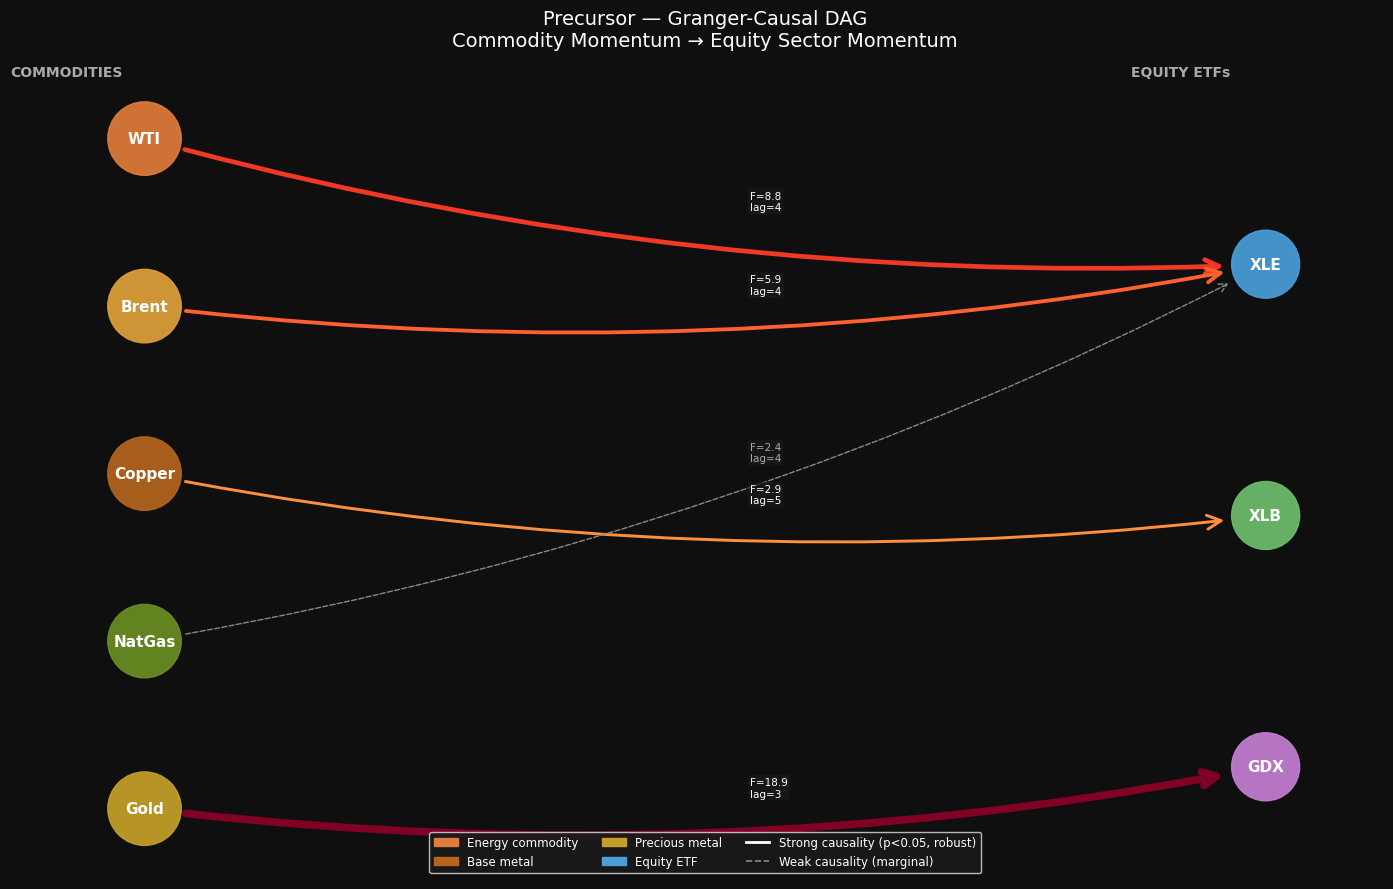

Saved: figures/05_dag.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 9), facecolor="#0f0f0f")
ax.set_facecolor("#0f0f0f")

# Layout: commodities on left, equities on right
pos = {
    "WTI"   : (0.0,  1.0),
    "Brent" : (0.0,  0.6),
    "Copper": (0.0,  0.2),
    "NatGas": (0.0, -0.2),
    "Gold"  : (0.0, -0.6),
    "XLE"   : (1.0,  0.7),
    "XLB"   : (1.0,  0.1),
    "GDX"   : (1.0, -0.5),
}

# Separate strong and weak edges
strong_edges = [(u, v) for u, v, d in G.edges(data=True) if not d["weak"]]
weak_edges   = [(u, v) for u, v, d in G.edges(data=True) if d["weak"]]
edge_weights = [G[u][v]["weight"] for u, v in strong_edges]

node_colors  = [NODE_COLORS[n] for n in G.nodes()]
node_sizes   = [2800 if n in COMMODITIES else 2400 for n in G.nodes()]

# Draw nodes
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.92)

# Draw strong edges
if strong_edges:
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edgelist=strong_edges,
                           width=[1.5 + 4.0 * w for w in edge_weights],
                           edge_color=[plt.cm.YlOrRd(0.4 + 0.6 * w) for w in edge_weights],
                           arrows=True,
                           arrowsize=25,
                           arrowstyle="->",
                           connectionstyle="arc3,rad=0.08",
                           min_source_margin=30,
                           min_target_margin=30)

# Draw weak edges (dashed)
if weak_edges:
    nx.draw_networkx_edges(G, pos, ax=ax,
                           edgelist=weak_edges,
                           width=1.0,
                           edge_color="#888888",
                           style="dashed",
                           arrows=True,
                           arrowsize=15,
                           arrowstyle="->",
                           connectionstyle="arc3,rad=0.08",
                           min_source_margin=30,
                           min_target_margin=30)

# Draw labels
nx.draw_networkx_labels(G, pos, ax=ax,
                        font_color="white",
                        font_size=11,
                        font_weight="bold")

# Edge annotations: F-stat and lag
for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    xm = (x0 + x1) / 2 + 0.04
    ym = (y0 + y1) / 2
    label = f"F={d['f_stat']:.1f}\nlag={d['opt_lag']}"
    color = "#aaaaaa" if d["weak"] else "white"
    ax.text(xm, ym, label, fontsize=7.5, color=color,
            ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="#1a1a1a", alpha=0.7, edgecolor="none"))

# Column labels
ax.text(-0.12, 1.15, "COMMODITIES", color="#aaaaaa", fontsize=10, fontweight="bold", transform=ax.transData)
ax.text(0.88,  1.15, "EQUITY ETFs", color="#aaaaaa", fontsize=10, fontweight="bold", transform=ax.transData)

# Legend
legend_elements = [
    mpatches.Patch(color="#e07b39", label="Energy commodity"),
    mpatches.Patch(color="#b5651d", label="Base metal"),
    mpatches.Patch(color="#c5a028", label="Precious metal"),
    mpatches.Patch(color="#4a9eda", label="Equity ETF"),
    plt.Line2D([0], [0], color="white",   linewidth=2,   label="Strong causality (p<0.05, robust)"),
    plt.Line2D([0], [0], color="#888888", linewidth=1.2, linestyle="--", label="Weak causality (marginal)"),
]
ax.legend(handles=legend_elements, facecolor="#1a1a1a", labelcolor="white",
          fontsize=8.5, loc="lower center", ncol=3, framealpha=0.9)

ax.set_title("Precursor — Granger-Causal DAG\nCommodity Momentum → Equity Sector Momentum",
             color="white", fontsize=14, pad=16)
ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_dag.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/05_dag.png")

---
### 5. Robustness — DAG Across Windows

Does the causal structure change across momentum windows? We build one DAG per window using only that window's significant results.

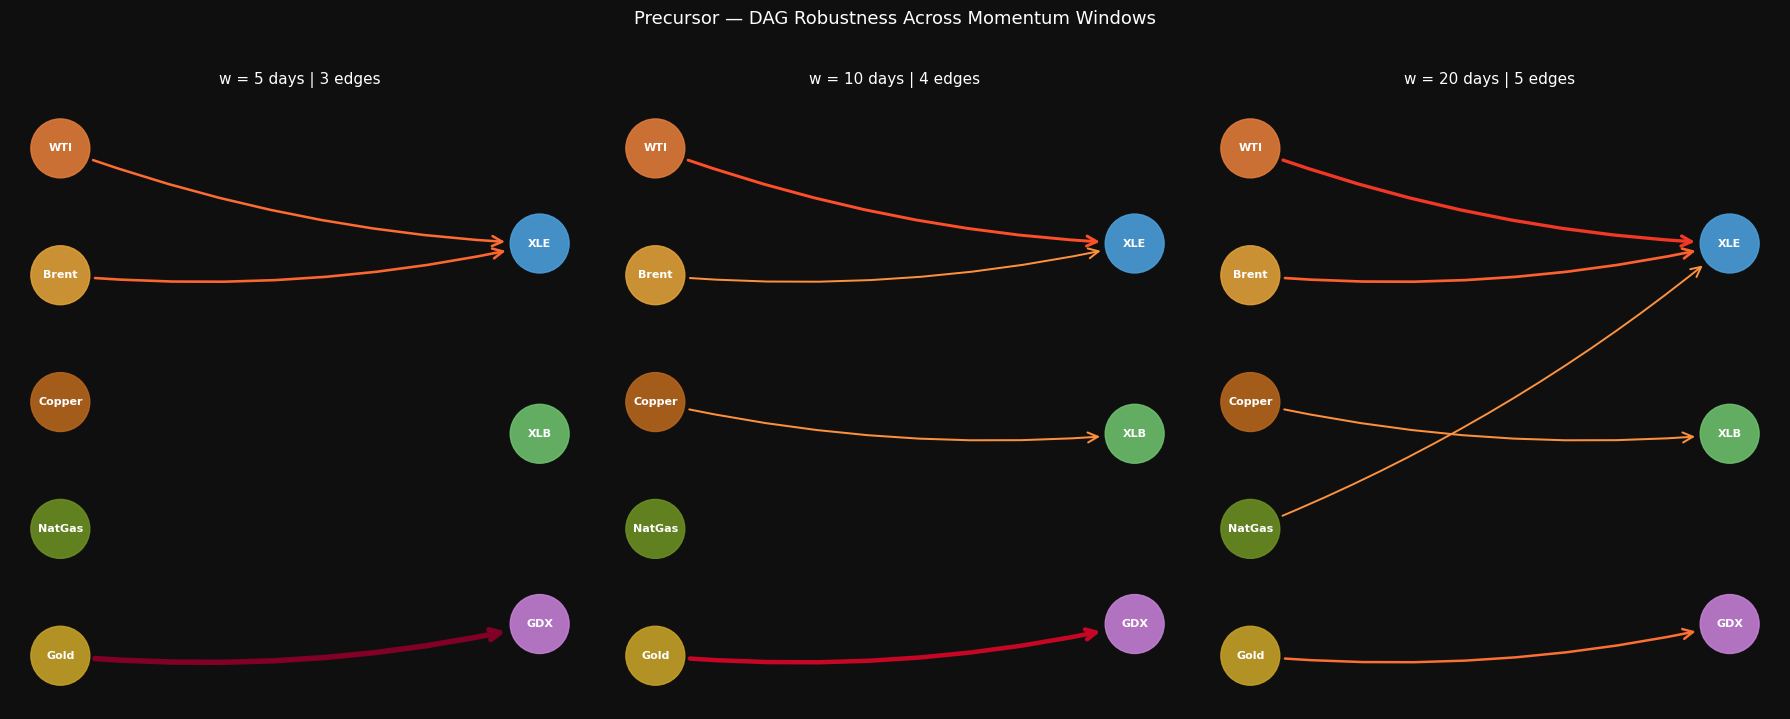

Saved: figures/05_dag_robustness.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor="#0f0f0f")

for col, w in enumerate(WINDOWS):
    ax = axes[col]
    ax.set_facecolor("#0f0f0f")

    # Build window-specific graph
    Gw = nx.DiGraph()
    for asset in ALL_ASSETS:
        Gw.add_node(asset)

    w_sig = results_df[(results_df["Window"] == w) & (results_df["Significant"])]
    # For each pair, take the lag with highest F-stat
    for (comm, eq), group in w_sig.groupby(["Commodity", "Equity"]):
        best = group.loc[group["F_stat"].idxmax()]
        Gw.add_edge(comm, eq,
                    weight  = best["F_stat"] / results_df["F_stat"].max(),
                    f_stat  = best["F_stat"],
                    opt_lag = int(best["Lag"]))

    node_colors_w = [NODE_COLORS[n] for n in Gw.nodes()]
    edges_w = list(Gw.edges())
    weights_w = [Gw[u][v]["weight"] for u, v in edges_w]

    nx.draw_networkx_nodes(Gw, pos, ax=ax, node_color=node_colors_w,
                           node_size=1800, alpha=0.9)

    if edges_w:
        nx.draw_networkx_edges(Gw, pos, ax=ax,
                               edgelist=edges_w,
                               width=[1.0 + 3.0 * wt for wt in weights_w],
                               edge_color=[plt.cm.YlOrRd(0.4 + 0.6 * wt) for wt in weights_w],
                               arrows=True, arrowsize=18,
                               arrowstyle="->",
                               connectionstyle="arc3,rad=0.08",
                               min_source_margin=25,
                               min_target_margin=25)

    nx.draw_networkx_labels(Gw, pos, ax=ax, font_color="white",
                            font_size=8, font_weight="bold")

    ax.set_title(f"w = {w} days | {Gw.number_of_edges()} edges",
                 color="white", fontsize=11, pad=8)
    ax.axis("off")

fig.suptitle("Precursor — DAG Robustness Across Momentum Windows",
             color="white", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_dag_robustness.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/05_dag_robustness.png")

---
### 6. Save Outputs

In [7]:
# Save centrality metrics
centrality_path = os.path.join(OUT_DIR, "dag_centrality.csv")
centrality_df.to_csv(centrality_path, index=False)
print(f"Saved: {centrality_path}")

# Save edge list
edge_records = []
for u, v, d in G.edges(data=True):
    edge_records.append({
        "From"      : u,
        "To"        : v,
        "F_stat"    : d["f_stat"],
        "Weight"    : round(d["weight"], 4),
        "Opt_Lag"   : d["opt_lag"],
        "Sig_Count" : d["sig_count"],
        "Weak"      : d["weak"]
    })
edge_df = pd.DataFrame(edge_records)
edge_path = os.path.join(OUT_DIR, "dag_edges.csv")
edge_df.to_csv(edge_path, index=False)
print(f"Saved: {edge_path}")
print(f"\nEdge list:")
print(edge_df.to_string(index=False))

Saved: ..\outputs\dag_centrality.csv
Saved: ..\outputs\dag_edges.csv

Edge list:
  From  To  F_stat  Weight  Opt_Lag  Sig_Count  Weak
   WTI XLE  8.7785  0.4646        4         11 False
 Brent XLE  5.8891  0.3117        4          7 False
Copper XLB  2.9297  0.1550        5          2 False
NatGas XLE  2.4287  0.1285        4          1  True
  Gold GDX 18.8961  1.0000        3         11 False


---
### 7. Summary

| Output | Path |
|---|---|
| DAG visualisation | `figures/05_dag.png` |
| DAG robustness plot | `figures/05_dag_robustness.png` |
| Centrality metrics | `outputs/dag_centrality.csv` |
| Edge list | `outputs/dag_edges.csv` |

**What to look for:**
- Gold has the highest weighted out-degree — strongest leading indicator
- XLE receives signal from 3 commodities (WTI, Brent, NatGas) — highest in-degree
- The robustness plot shows which edges are stable across all 3 windows vs window-dependent
- NatGas → XLE appears only in the w=20 panel — confirms it as a weak/marginal finding

**Next:** `06_backtest.ipynb` — construct and evaluate a signal-based long/short strategy using optimal lags from the Granger results.